<a href="https://colab.research.google.com/github/youkjang/gefs_temperature_spread_error/blob/main/notebooks/gefs_temperature_spread_error.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#GEFS Temperature Spread-Error Relationship

This notebook examines the relationship between GEFS ensemble spread and 2-meter temperature forecast error over the CONUS region.

##Goal
Evaluate if GEFS ensemble spread is reliable indicator of actual forecast uncertainty.

##Workflow

1. Configuration: Initial Dates, Forecast hours (25,48,72, and 96), and the ensemble number.
2. Access CEFS 2-meter temperature forecast files from Amazon S3 using fsspec.
3. Read GRIB2 files using xarray and cfgrib.
4. Load multiple GEFS ensemble members.
5. Calculate ensemble mean, ensemble spread,
6. Load the GFS as a verifying analysis field.
7. Calculate absolute forecast error.
8. Plot ensemble spread and forecast error with lead time.
9. Plot the scatter plot of spread and error.



##1. Install packages

In [1]:
!pip install cartopy

In [2]:
!pip -q install "eccodes>=2.37.0" cfgrib s3fs "fsspec==2025.3.0"

Install GitHub repository

In [4]:
!pip install git+https://github.com/youkjang/gefs_temperature_spread_error.git

  Cloning https://github.com/youkjang/gefs_temperature_spread_error.git to /tmp/pip-req-build-os011618
  Running command git clone --filter=blob:none --quiet https://github.com/youkjang/gefs_temperature_spread_error.git /tmp/pip-req-build-os011618
  Resolved https://github.com/youkjang/gefs_temperature_spread_error.git to commit 61c4b58af8e206120b3a5c7cfaab0318a6001410
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


##2. Import packages and GitHub repository


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

Import modules from my GitHub: config, data_access, verification, plotting

In [5]:
from gefs_spread_error.config import ProjectConfig

from gefs_spread_error.data_access import (
    load_gefs_member_t2m,
    load_gfs_analysis_t2m,
)

from gefs_spread_error.verification import (
    stack_members,
    ensemble_mean,
    ensemble_spread,
    forecast_error,
    rmse,
    mean_absolute_error,
    domain_mean,
    kelvin_to_celsius,
)

from gefs_spread_error.plotting import (
    plot_spread_rmse_by_lead,
    plot_spread_error_scatter,
)

##3. Set configuration

In [6]:
config = ProjectConfig(
    init_date="20260510",
    init_hour="00",
)

config.forecast_hours = [24, 48, 72, 96]

# Start small for Colab
config.members = [f"gep{i:02d}" for i in range(1, 11)]

config

ProjectConfig(init_date='20260510', init_hour='00', forecast_hours=[24, 48, 72, 96], members=['gep01', 'gep02', 'gep03', 'gep04', 'gep05', 'gep06', 'gep07', 'gep08', 'gep09', 'gep10'], lon_min=230.0, lon_max=300.0, lat_min=20.0, lat_max=55.0, variable='t2m', gefs_bucket='noaa-gefs-pds', gfs_bucket='noaa-gfs-bdp-pds')

##4. Test one GEFS member and one GFS analysis

In [7]:
test_fhr = 24
test_member = config.members[0]

gefs_t2m = load_gefs_member_t2m(config, test_member, test_fhr)
gfs_t2m = load_gfs_analysis_t2m(config, test_fhr)

print(gefs_t2m)
print(gfs_t2m)

<xarray.DataArray 't2m' (latitude: 141, longitude: 281)> Size: 158kB
[39621 values with dtype=float32]
Coordinates:
  * latitude           (latitude) float64 1kB 55.0 54.75 54.5 ... 20.25 20.0
  * longitude          (longitude) float64 2kB 230.0 230.2 230.5 ... 299.8 300.0
    number             int64 8B ...
    time               datetime64[ns] 8B ...
    step               timedelta64[ns] 8B ...
    heightAboveGround  float64 8B ...
    valid_time         datetime64[ns] 8B ...
Attributes: (12/31)
    GRIB_paramId:                             167
    GRIB_dataType:                            pf
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         heightAboveGround
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           2t
    GRIB_totalNumber:                         30
    GRIB_units:              

##5. Quick map check

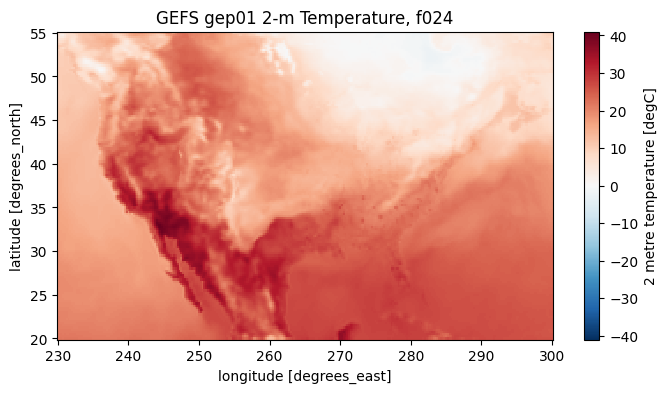

In [8]:
gefs_t2m_c = kelvin_to_celsius(gefs_t2m)

plt.figure(figsize=(8, 4))
gefs_t2m_c.plot()
plt.title(f"GEFS {test_member} 2-m Temperature, f{test_fhr:03d}")
plt.show()

##6. Compute spread and error for each forecast lead time
For each forecast hour, this loop:

1. Loads GEFS members.
2. Stacks members into an ensemble.
3. Computes ensemble mean.
4. Computes ensemble spread.
5. Loads verifying GFS analysis.
6. Computes forecast error.
7. Saves CONUS-average metrics.

In [9]:
summary_rows = []
results_by_fhr = {}

for fhr in config.forecast_hours:
    print(f"Processing forecast hour f{fhr:03d}")

    member_arrays = []

    for member in config.members:
        print(f"  loading {member}")
        da = load_gefs_member_t2m(config, member, fhr)
        member_arrays.append(da)

    # Stack members into one ensemble DataArray
    ens = stack_members(member_arrays)

    # Ensemble mean and spread
    ens_mean = ensemble_mean(ens)
    spread = ensemble_spread(ens)

    # Verifying field: GFS analysis valid at forecast time
    analysis = load_gfs_analysis_t2m(config, fhr)

    # Forecast error = ensemble mean forecast - analysis
    error = forecast_error(ens_mean, analysis)

    row = {
        "forecast_hour": fhr,
        "spread_mean": domain_mean(spread),
        "rmse": rmse(error),
        "mae": mean_absolute_error(error),
        "bias": domain_mean(error),
        "n_members": len(config.members),
    }

    summary_rows.append(row)

    results_by_fhr[fhr] = {
        "ensemble": ens,
        "ensemble_mean": ens_mean,
        "spread": spread,
        "analysis": analysis,
        "error": error,
    }

results_df = pd.DataFrame(summary_rows)
results_df

Processing forecast hour f024
  loading gep01
  loading gep02
  loading gep03
  loading gep04
  loading gep05
  loading gep06
  loading gep07
  loading gep08
  loading gep09
  loading gep10
Processing forecast hour f048
  loading gep01
  loading gep02
  loading gep03
  loading gep04
  loading gep05
  loading gep06
  loading gep07
  loading gep08
  loading gep09
  loading gep10
Processing forecast hour f072
  loading gep01
  loading gep02
  loading gep03
  loading gep04
  loading gep05
  loading gep06
  loading gep07
  loading gep08
  loading gep09
  loading gep10
Processing forecast hour f096
  loading gep01
  loading gep02
  loading gep03
  loading gep04
  loading gep05
  loading gep06
  loading gep07
  loading gep08
  loading gep09
  loading gep10


,forecast_hour,spread_mean,rmse,mae,bias,n_members
0,24,0.641240,1.199409,0.730131,0.258650,10
1,48,0.822519,1.320308,0.900733,0.222449,10
2,72,0.976914,1.619356,1.146307,0.483218,10
3,96,1.367494,3.358136,1.867321,1.125346,10


##7. Plot spread and RMSE with lead time

- Both lines increase with forecast hour, and GEFS uncertainty and forecast error both grow with lead time.
- Spread is much smaller than RMSE, and the ensemble may be underdispersive.


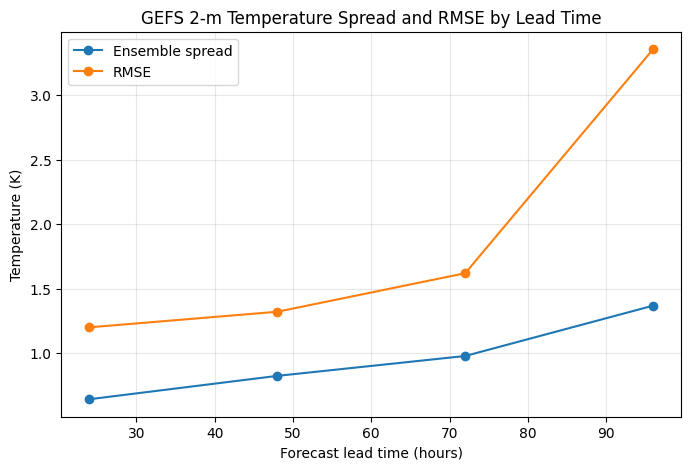

In [10]:
fig, ax = plot_spread_rmse_by_lead(
    results_df,
    output_path="../figures/spread_error_lead_time.png"
)

plt.show()

##8. Scatter plot
### Grid-point spread vs Absoulte error



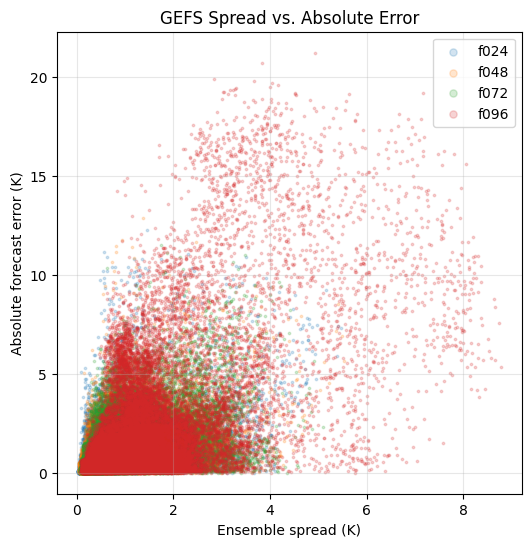

In [11]:
fig, ax = plot_spread_error_scatter(
    results_by_fhr,
    output_path="../figures/spread_vs_absolute_error_scatter.png"
)

plt.show()

##Select 24, 48, and 72 forecast hours
- 96 forecast hours: some grid points show 20K foreast errors.
- Here, only 24, 48, and 72 forecast hours are plotted.

In [12]:
selected_forecast_hours = [24, 48, 72]
filtered_results_by_fhr = {fhr: results_by_fhr[fhr] for fhr in selected_forecast_hours if fhr in results_by_fhr}

print(f"Original results_by_fhr keys: {list(results_by_fhr.keys())}")
print(f"Filtered results_by_fhr keys: {list(filtered_results_by_fhr.keys())}")

Original results_by_fhr keys: [24, 48, 72, 96]
Filtered results_by_fhr keys: [24, 48, 72]


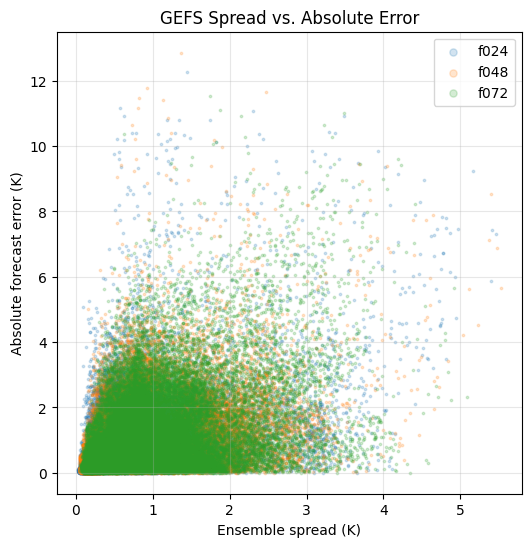

In [13]:
fig, ax = plot_spread_error_scatter(
    filtered_results_by_fhr,
   #output_path="../figures/spread_vs_absolute_error_scatter.png"
)

plt.show()

##9. Spread-error correlation

- Calculated using grid points from all selected forecast lead times.

- Positive correlation: larger spread tends to occur where absolute error is larger.


In [14]:
all_spread = []
all_abs_error = []

for fhr, data in results_by_fhr.items():
    all_spread.append(data["spread"].values.ravel())
    all_abs_error.append(np.abs(data["error"].values.ravel()))

all_spread = np.concatenate(all_spread)
all_abs_error = np.concatenate(all_abs_error)

mask = np.isfinite(all_spread) & np.isfinite(all_abs_error)

corr = np.corrcoef(all_spread[mask], all_abs_error[mask])[0, 1]

print(f"Grid-point spread-error correlation: {corr:.3f}")

Grid-point spread-error correlation: 0.535


## 10. Conclusion

This notebook evaluated the relationship between GEFS ensemble spread and forecast error for 2-m temperature over CONUS.

For each forecast lead time, GEFS ensemble members were used to calculate:

- ensemble mean
- ensemble spread
- forecast error
- RMSE
- mean absolute error
- bias

The main diagnostic compared the CONUS-mean ensemble spread with RMSE from +24 h to +96 h.

- Ensemble spread and RMSE both increase with forecast lead time, so this suggests that GEFS uncertainty grows consistently with forecast error.

###Ensemble spread < Forecast error
- The ensemble spread is overconfident.
- The ensemble does not fully represent all sources of uncertainty.
- Initial-condition perturbations may not be large enough.
- Physics or land-surface uncertainty may be underrepresented.



###Note on AI Assistance

This notebook was developed with AI-assisted coding support. See the repository README for details.